In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
#sns.set_style('whitegrid')
#plt.style.use("fivethirtyeight")
#%matplotlib inline

# Extracting stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr
import pandas_datareader as data

# Traditional machine learning
#implementing KNN Classifier, LogisticRegression and RandomForestClassifier
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import warnings
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
warnings.simplefilter(action = 'ignore', category = FutureWarning)

# LSTM 
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
from keras.losses import BinaryCrossentropy
from sklearn.metrics import r2_score
from keras.callbacks import ModelCheckpoint

# For time stamps
from datetime import datetime

C:\Users\joyma\anaconda3\lib\site-packages\yfinance\base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [4]:

yf.pdr_override()


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Set up End and Start times for data grab
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)


In [5]:

for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)
    

company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name
    
df = pd.concat(company_list, axis=0)
df.tail(10)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2024-04-24,179.940002,180.320007,176.179993,176.589996,176.589996,34185100,AMAZON
2024-04-25,169.679993,173.919998,166.320007,173.669998,173.669998,49249400,AMAZON
2024-04-26,177.800003,180.820007,176.130005,179.619995,179.619995,43919800,AMAZON
2024-04-29,182.750000,183.529999,179.389999,180.960007,180.960007,54063900,AMAZON
2024-04-30,181.089996,182.990005,174.800003,175.000000,175.000000,94639800,AMAZON
2024-05-01,181.639999,185.149994,176.559998,179.000000,179.000000,94645100,AMAZON
2024-05-02,180.850006,185.100006,179.910004,184.720001,184.720001,54303500,AMAZON
2024-05-03,186.990005,187.869995,185.419998,186.210007,186.210007,39172000,AMAZON
2024-05-06,186.279999,188.750000,184.800003,188.699997,188.699997,34653900,AMAZON


In [6]:
df.head(10)

,Open,High,Low,Close,Adj Close,Volume,company_name
Date,,,,,,,
2023-05-08,172.479996,173.850006,172.110001,173.500000,172.578827,55962800,APPLE
2023-05-09,173.050003,173.539993,171.600006,171.770004,170.858032,45326900,APPLE
2023-05-10,173.020004,174.029999,171.899994,173.559998,172.638519,53724500,APPLE
2023-05-11,173.850006,174.589996,172.169998,173.750000,172.827484,49514700,APPLE
2023-05-12,173.619995,174.059998,171.000000,172.570007,171.891205,45497800,APPLE
2023-05-15,173.160004,173.210007,171.470001,172.070007,171.393173,37266700,APPLE
2023-05-16,171.990005,173.139999,171.800003,172.070007,171.393173,42110300,APPLE
2023-05-17,171.710007,172.929993,170.419998,172.690002,172.010727,57951600,APPLE
2023-05-18,173.000000,175.240005,172.580002,175.050003,174.361450,65496700,APPLE


In [7]:
df.size

7056

In [8]:
df.shape

(1008, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1008 entries, 2023-05-08 to 2024-05-07
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1008 non-null   float64
 1   High          1008 non-null   float64
 2   Low           1008 non-null   float64
 3   Close         1008 non-null   float64
 4   Adj Close     1008 non-null   float64
 5   Volume        1008 non-null   int64  
 6   company_name  1008 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 63.0+ KB


In [10]:
AAPL.describe()

,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,181.355556,182.818254,179.973730,181.430298,181.061887,5.815842e+07
std,8.586440,8.434531,8.555815,8.533714,8.473650,1.867144e+07
min,165.350006,166.399994,164.080002,165.000000,165.000000,2.404830e+07
25%,173.747494,175.375000,172.417500,173.750000,173.494946,4.674302e+07
50%,181.065002,182.434998,179.144997,180.955002,180.449684,5.368500e+07
75%,189.277496,189.990005,187.652500,189.317501,188.879902,6.465378e+07
max,198.020004,199.619995,197.000000,198.110001,197.857529,1.632241e+08


In [11]:
GOOG.describe()

,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,136.727020,138.242762,135.524306,136.933254,136.933254,2.306338e+07
std,12.248526,12.219872,12.107948,12.216731,12.216731,8.707445e+06
min,105.794998,108.419998,105.790001,107.940002,107.940002,8.828600e+06
25%,129.120003,130.097504,127.831249,128.625000,128.625000,1.763922e+07
50%,136.180000,137.669998,135.060501,136.519997,136.519997,2.072940e+07
75%,143.415001,144.491245,141.887505,143.052498,143.052498,2.517182e+07
max,175.990005,176.419998,171.399994,173.690002,173.690002,5.879610e+07


In [12]:
MSFT.describe()

,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,362.956904,365.968136,359.759246,362.970794,361.913232,2.435993e+07
std,37.290478,37.178223,37.031750,37.191079,37.847694,9.174919e+06
min,308.000000,309.899994,306.089996,307.000000,304.500885,5.983840e+06
25%,331.172493,333.512497,327.307487,329.887505,328.541885,1.872188e+07
50%,356.485001,362.459991,352.895004,358.009995,356.247055,2.225760e+07
75%,403.037498,405.642502,398.590012,402.327499,402.197495,2.694188e+07
max,429.829987,430.820007,427.160004,429.369995,429.369995,7.847820e+07


In [13]:
AMZN.describe()

,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,146.592103,148.198770,145.034088,146.693869,146.693869,5.073984e+07
std,21.265914,21.313084,21.093207,21.218478,21.218478,1.813685e+07
min,105.040001,106.099998,104.699997,105.830002,105.830002,1.514457e+07
25%,129.712502,131.342495,128.332504,129.330002,129.330002,4.063025e+07
50%,141.025002,143.345001,140.000000,142.404999,142.404999,4.725675e+07
75%,168.790005,170.452499,166.525005,168.767498,168.767498,5.597245e+07
max,188.929993,189.940002,188.110001,189.375000,189.375000,1.529387e+08


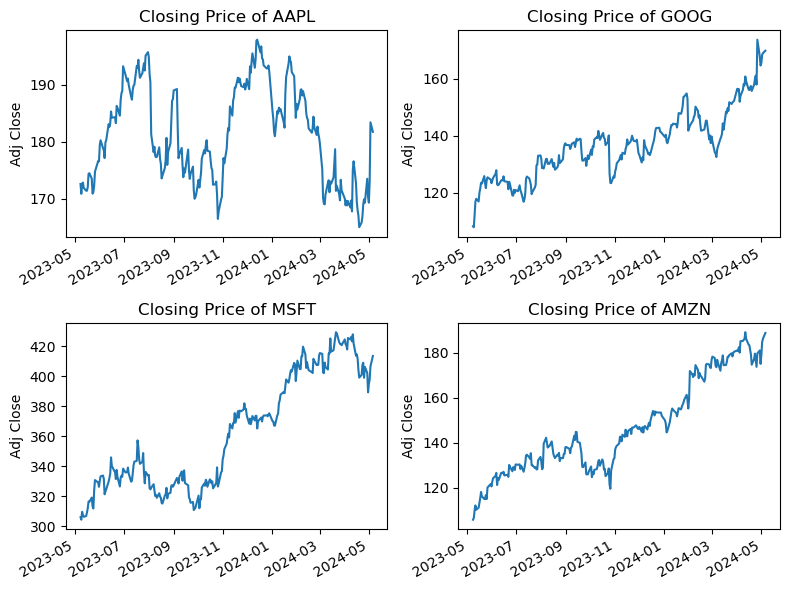

In [12]:
# Historical view of the closing price for each company
plt.figure(figsize=(8, 6))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Adj Close'].plot()
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")
    
plt.tight_layout()

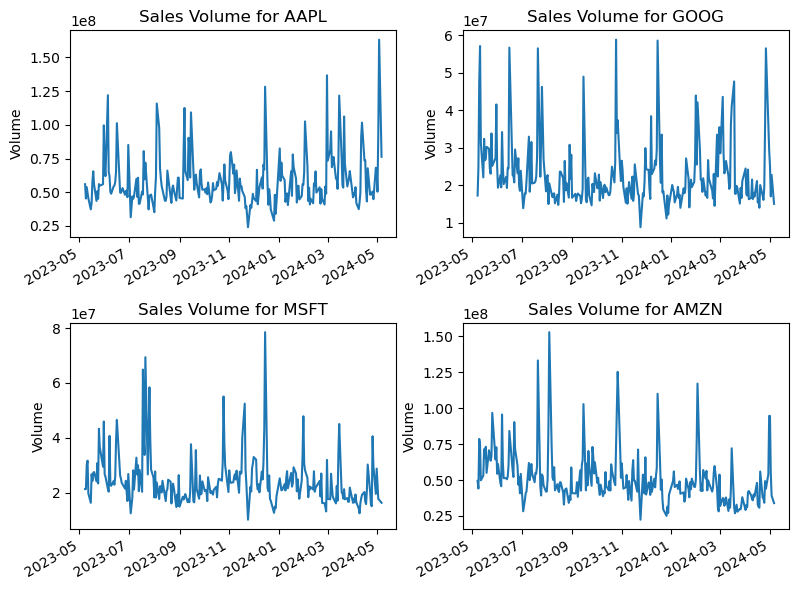

In [13]:
# Volume of stock traded each day for each company 
plt.figure(figsize=(8, 6))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")
    
plt.tight_layout()

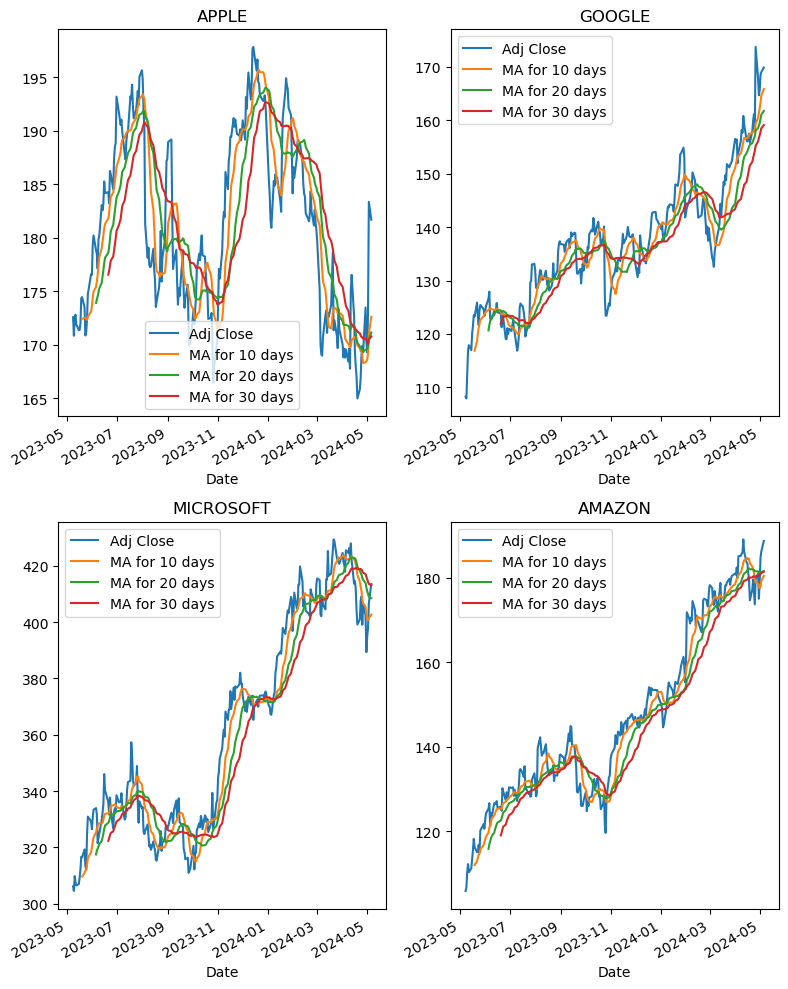

In [14]:
# Moving Average of various stock 
ma_day = [10, 20, 30]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()
        

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(8)

AAPL[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

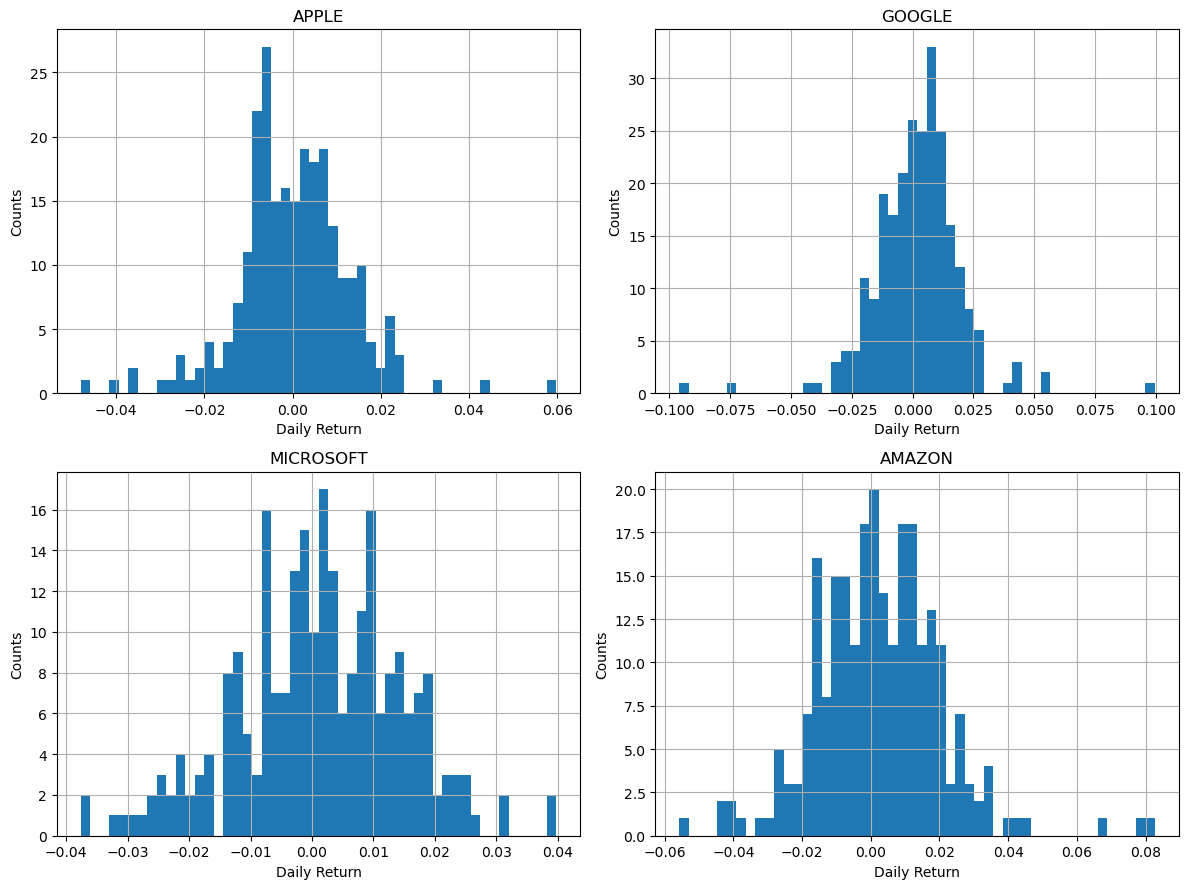

In [15]:
# Average daily return using Histogram
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    company['Daily Return'] = company['Adj Close'].pct_change()
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')
    
plt.tight_layout()

In [16]:
# closing prices of tech stock list into a DataFrame

closing_df = pdr.get_data_yahoo(tech_list, start=start, end=end)['Adj Close']

# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head()

[*********************100%%**********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2023-05-08,NaN,NaN,NaN,NaN
2023-05-09,-0.009971,0.007465,-0.002772,-0.005346
2023-05-10,0.010421,0.033483,0.040207,0.017296
2023-05-11,0.001095,0.018060,0.041147,-0.007044
2023-05-12,-0.005418,-0.017115,0.008725,-0.003676


Text(0.5, 1.0, 'Correlation of stock closing price')

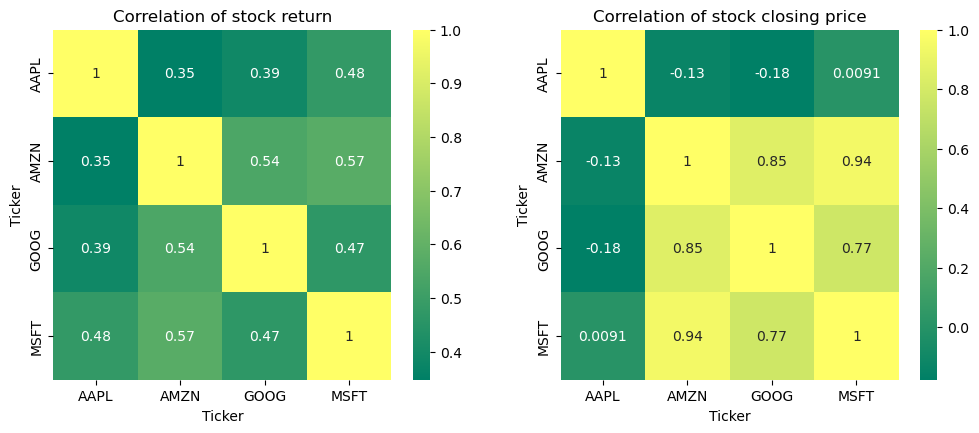

In [17]:
#  correlation plot of stock return and stock closing price
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

In [18]:
# Predicting closing price (Regression Problen)

# Model for Google Stock

In [14]:
# Get the stock quote for Google
GG_df = pdr.get_data_yahoo('GOOG', start='2013-01-01', end=datetime.now())
# Show teh data
GG_df

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-01-02,17.918339,18.107130,17.846855,18.013729,18.013729,102033017
2013-01-03,18.055573,18.229919,17.950716,18.024191,18.024191,93075567
2013-01-04,18.165413,18.467529,18.124067,18.380356,18.380356,110954331
2013-01-07,18.317591,18.415474,18.196297,18.300158,18.300158,66476239
2013-01-08,18.319834,18.338762,18.043119,18.264042,18.264042,67295297
...,...,...,...,...,...,...
2024-05-01,166.179993,168.809998,164.899994,165.570007,165.570007,25223200
2024-05-02,166.669998,168.529999,165.690002,168.460007,168.460007,17041100
2024-05-03,169.539993,169.850006,164.979996,168.990005,168.990005,22767100


In [20]:
GG_df.shape[0]

2855

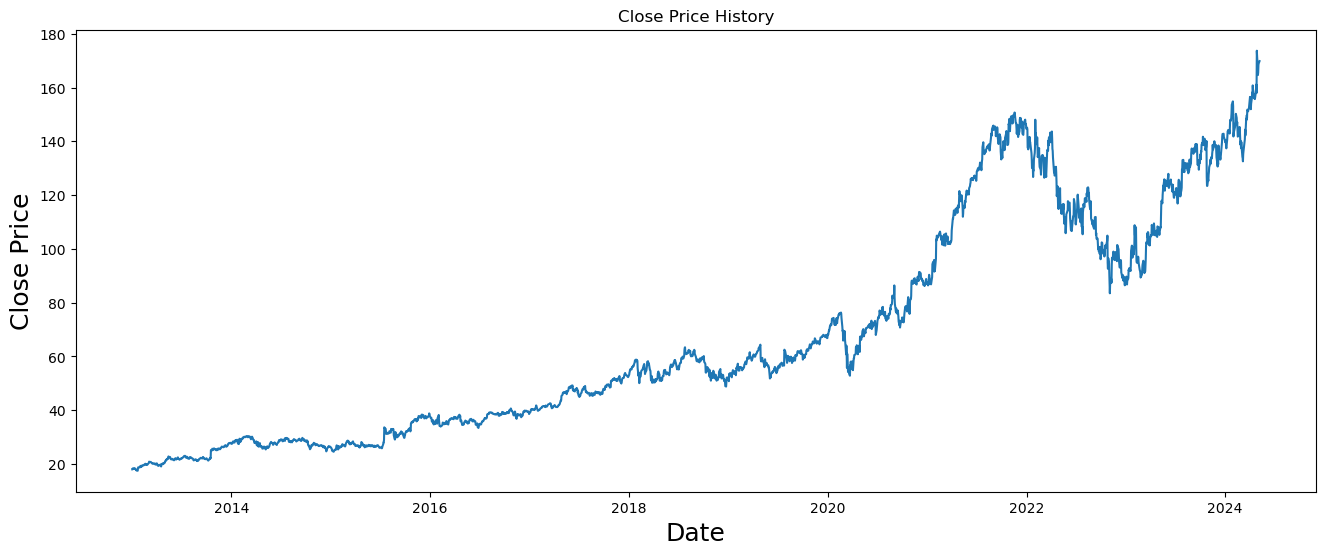

In [21]:
# Closing Price
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(GG_df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

In [22]:
# Removing row that contains NAN values
GG_df.dropna(inplace=True)

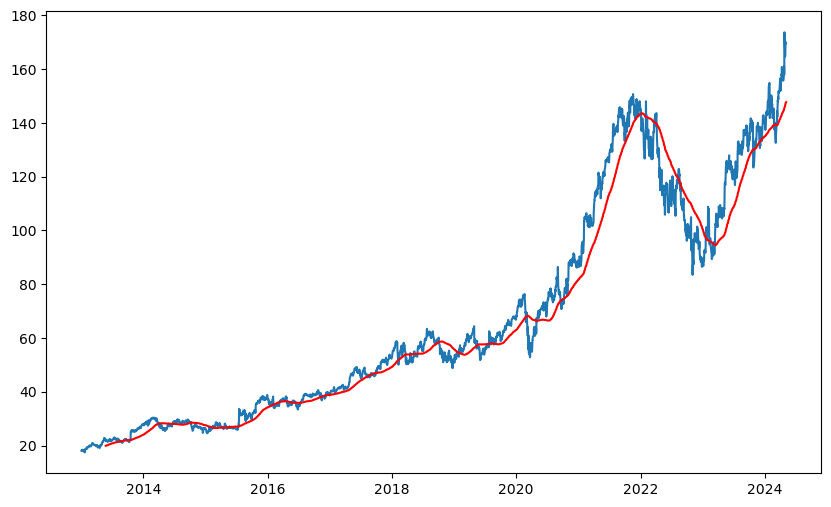

In [23]:
# Rolling average for 100days
ma100 = GG_df.Close.rolling(100).mean()
plt.figure(figsize = (10,6))
plt.plot(GG_df.Close)
plt.plot(ma100, 'r')

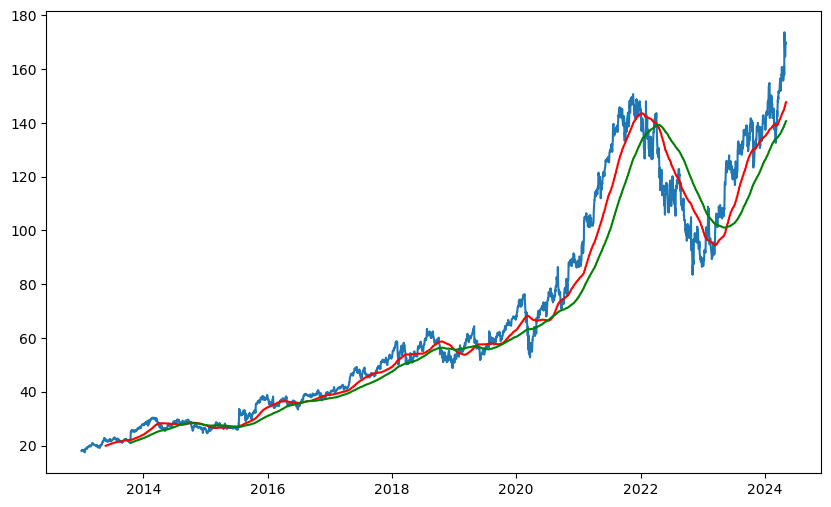

In [24]:
# Rolling average for 200days
ma200 = GG_df.Close.rolling(200).mean()
plt.figure(figsize = (10,6))
plt.plot(GG_df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [25]:
# Traditional machine learning for stock prediction KNN, random Forest, Support Vector Machines (SVM).

In [30]:
GG_df.reset_index(inplace=True)

In [31]:
# Making Date as a column
columns = GG_df.columns

In [32]:
GG_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2856 non-null   datetime64[ns]
 1   Open       2856 non-null   float64       
 2   High       2856 non-null   float64       
 3   Low        2856 non-null   float64       
 4   Close      2856 non-null   float64       
 5   Adj Close  2856 non-null   float64       
 6   Volume     2856 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 156.3 KB


In [33]:
GG_df.set_index('Date', inplace=True)

In [34]:
# Getting the value for features
GG_df['Open - Close'] = GG_df['Open'] - GG_df['Close']
GG_df['High - Low'] = GG_df['High'] - GG_df['Low']

In [35]:
M = GG_df[['Open - Close', 'High - Low']]
M.head(10)

,Open - Close,High - Low
Date,,
2013-01-02,-0.095390,0.260275
2013-01-03,0.031382,0.279203
2013-01-04,-0.214943,0.343462
2013-01-07,0.017433,0.219177
2013-01-08,0.055792,0.295643
2013-01-09,-0.145704,0.242840
2013-01-10,0.033625,0.286427
2013-01-11,0.050062,0.152678
2013-01-14,0.342466,0.494396


In [36]:
# Target value
N = GG_df['Close']

In [37]:
# Creating a KNN
m_train_reg, m_test_reg, n_train_reg, n_test_reg = train_test_split(M, N, test_size = 0.25, random_state = 40)


knn_reg = KNeighborsRegressor(n_neighbors = 5)

#fit the model
knn_reg.fit(m_train_reg, n_train_reg)


prediction_Knn_GG = knn_reg.predict(m_test_reg)

GG_mse = mean_squared_error(n_test_reg, prediction_Knn_GG)
print(f'Mean Squared Error: {GG_mse}')
print(f'R2: {r2_score(n_test_reg, prediction_Knn_GG)}')
GG_r2 = r2_score(n_test_reg, prediction_Knn_GG)

Mean Squared Error: 536.427781126664
R2: 0.6571817106581255


In [38]:
# rmse (Root Mean Square Error)
GG_rms = np.sqrt(np.mean(np.power((np.array(n_test_reg) -np.array(prediction_Knn_GG)), 2)))
GG_rms

23.16091062818265

In [39]:
# Create a Random Forest regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_reg.fit(m_train_reg, n_train_reg)

# Make predictions on the test set
prediction_rf_GG = rf_reg.predict(m_test_reg)

# Evaluate the model
GG_rf_mse = mean_squared_error(n_test_reg, prediction_rf_GG)
print(f'Mean Squared Error: {GG_rf_mse}')
print(f'R2: {r2_score(n_test_reg, prediction_rf_GG)}')
GG_rf_r2 = r2_score(n_test_reg, prediction_rf_GG)

Mean Squared Error: 580.1542883895087
R2: 0.6292371355519307


In [40]:
# rmse (Root Mean Square Error)
GG_rms_rf = np.sqrt(np.mean(np.power((np.array(n_test_reg) -np.array(prediction_rf_GG)), 2)))
GG_rms_rf

24.08639218292164

In [41]:
# Create an SVR model
svm_reg = SVR(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', etc.

# Fit the model to the training data
svm_reg.fit(m_train_reg, n_train_reg)

# Make predictions on the test set
prediction_svm_GG = svm_reg.predict(m_test_reg)

# Evaluate the model using Mean Squared Error
GG_mse_svm = mean_squared_error(n_test_reg, prediction_svm_GG)
print(f'Mean Squared Error: {GG_mse_svm}')
print(f'R2: {r2_score(n_test_reg, prediction_svm_GG)}')
GG_svm_r2 = r2_score(n_test_reg, prediction_svm_GG)

Mean Squared Error: 774.0436066648638
R2: 0.5053270646133703


In [42]:
# rmse (Root Mean Square Error)
GG_rms_svm = np.sqrt(np.mean(np.power((np.array(n_test_reg) -np.array(prediction_svm_GG)), 2)))
GG_rms_svm

27.82163918004947

In [43]:
#prediction_Google

Actual_predicted_GG = pd.DataFrame({'Actual Class': n_test_reg, 'Knn_reg Predicted Class': prediction_Knn_GG, 'Rf_reg Predicted Class': prediction_rf_GG, 'svm_reg Predicted Class': prediction_svm_GG})

Actual_predicted_GG.tail(10)

,Actual Class,Knn_reg Predicted Class,Rf_reg Predicted Class,svm_reg Predicted Class
Date,,,,
2021-04-07,112.484001,55.849200,55.718030,70.604590
2023-03-13,91.660004,108.639001,124.423727,118.846607
2021-09-02,144.218994,93.332300,75.355830,83.585596
2021-10-18,142.960495,89.082299,87.257601,81.107280
2013-09-03,21.429178,26.181096,34.546612,33.092452
2022-06-30,109.372498,118.590898,113.525878,138.078724
2020-07-15,75.681999,89.063902,87.116551,76.968063
2017-08-10,45.362000,38.791196,39.982573,41.432402
2014-09-08,29.405268,31.832852,29.282210,32.169206


In [40]:
# Building LSTM Model

In [15]:
GG_data = GG_df.filter(['Close'])
GG_dataset = GG_data.values

In [16]:
GG_training_data_len = int(np.ceil( len(GG_dataset) * .80 ))
GG_training_data_len

2285

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
GG_scaled_data = scaler.fit_transform(GG_dataset)

In [18]:
# Create the training data set & scaled training data set
GG_train_data = GG_scaled_data[0:int(GG_training_data_len), :]
# Split the data into x_train and y_train data sets
L_m_train = []
L_n_train = []

for i in range(100, len(GG_train_data)):
    L_m_train.append(GG_train_data[i-100:i, 0])
    L_n_train.append(GG_train_data[i, 0])
    if i<= 61:
        print(L_m_train)
        print(L_n_train)
        print()
        
# Convert the L_m_train and L_n_train to numpy arrays 
L_m_train, L_n_train = np.array(L_m_train), np.array(L_n_train)

# Reshape the data
L_m_train = np.reshape(L_m_train, (L_m_train.shape[0], L_m_train.shape[1], 1))

In [19]:

# Define your model architecture

model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((L_m_train.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = [ 'mean_squared_error'])

model.fit(L_m_train,L_n_train, epochs = 50, batch_size =32, verbose =1)



Epoch 1/50
69/69 [==============================] - 22s 218ms/step - loss: 0.0180 - mean_squared_error: 0.0180
Epoch 2/50
69/69 [==============================] - 14s 208ms/step - loss: 0.0032 - mean_squared_error: 0.0032
Epoch 3/50
69/69 [==============================] - 19s 281ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 4/50
69/69 [==============================] - 20s 296ms/step - loss: 0.0028 - mean_squared_error: 0.0028
Epoch 5/50
69/69 [==============================] - 14s 201ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 6/50
69/69 [==============================] - 13s 188ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 7/50
69/69 [==============================] - 15s 214ms/step - loss: 0.0024 - mean_squared_error: 0.0024
Epoch 8/50
69/69 [==============================] - 15s 223ms/step - loss: 0.0023 - mean_squared_error: 0.0023
Epoch 9/50
69/69 [==============================] - 15s 213ms/step - loss: 0.0025 - mean_squared_error: 0.0025
E

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_1 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_2 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [21]:
GG_test_data = GG_scaled_data[GG_training_data_len - 100: , :]
# Create the data sets L_m_test and L_n_test
L_m_test = []
L_n_test = GG_dataset[GG_training_data_len:, :]
for i in range(100, len(GG_test_data)):
    L_m_test.append(GG_test_data[i-100:i, 0])
    
# Convert the data to a numpy array
L_m_test = np.array(L_m_test)

# Reshape the data
L_m_test = np.reshape(L_m_test, (L_m_test.shape[0], L_m_test.shape[1], 1 ))

# Get the models predicted price values 
GG_predictions = model.predict(L_m_test)
GG_predictions = scaler.inverse_transform(GG_predictions)

18/18 [==============================] - 3s 67ms/step


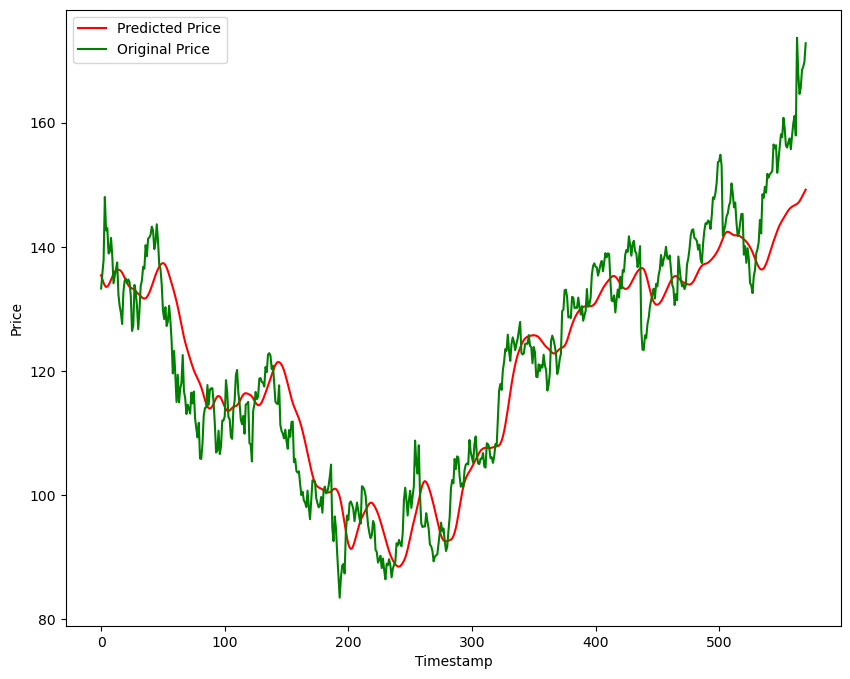

In [22]:
plt.figure(figsize=(10,8))
plt.plot(GG_predictions, 'r', label = 'Predicted Price')
plt.plot(L_n_test, 'g', label = 'Original Price')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()


C:\Users\joyma\AppData\Local\Temp\ipykernel_4412\2676798533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GG_valid['Predictions'] = GG_predictions


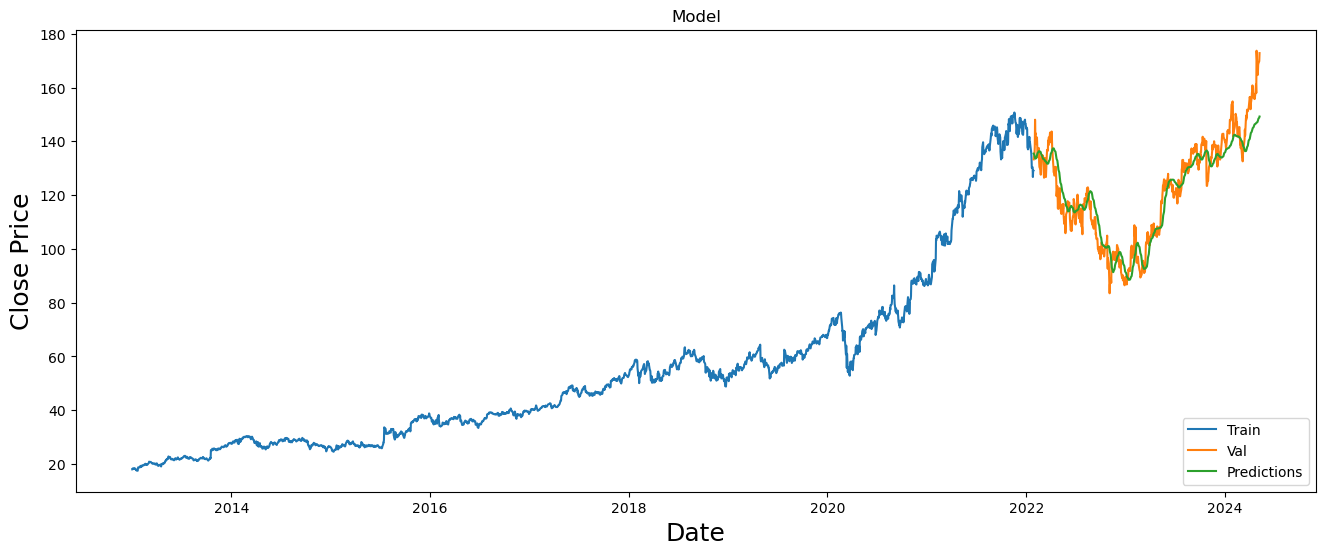

In [23]:
# Plot the data
GG_train = GG_data[:GG_training_data_len]
GG_valid = GG_data[GG_training_data_len:]
GG_valid['Predictions'] = GG_predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.plot(GG_train['Close'])
plt.plot(GG_valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


In [24]:
# Calculate R-squared manually
GG_r_squared = r2_score(GG_data[GG_training_data_len:], GG_predictions)
print(f'R-squared: {GG_r_squared}')

R-squared: 0.8760691099508061


In [25]:
GG_mse_LSTM = mean_squared_error(L_n_test, GG_predictions)
GG_mse_LSTM

46.293966926329205

In [26]:
# Get the root mean squared error (RMSE)
GG_rmse = np.sqrt(np.mean(((GG_predictions - L_n_test) ** 2)))
GG_rmse

6.8039669992093

In [27]:
GG_valid.tail(10)

,Close,Predictions
Date,,
2024-04-24,161.100006,146.701401
2024-04-25,157.949997,146.809692
2024-04-26,173.690002,146.931259
2024-04-29,167.899994,147.094193
2024-04-30,164.639999,147.353043
2024-05-01,165.570007,147.685822
2024-05-02,168.460007,148.054550
2024-05-03,168.990005,148.436691
2024-05-06,169.830002,148.825241


In [28]:
model.save('GG_Stock_Market_Prediction.h5')

In [44]:
R2_result = pd.DataFrame([['Knn', GG_r2], ['Rf', GG_rf_r2], ['Svm',GG_svm_r2], ['Lstm', GG_r_squared]], columns=['Google_Model', 'Result'])
print(R2_result)

  Google_Model    Result
0          Knn  0.657182
1           Rf  0.629237
2          Svm  0.505327
3         Lstm  0.876069


In [45]:
import numpy as np

import lime

from lime import lime_tabular

from keras.models import Sequential

from keras.layers import LSTM, Dropout, Dense

from keras.optimizers import Adam
 

 
# Your existing model code here...
 
# Define a prediction function that LIME can use

def predict_function(x):

    x = x.reshape((x.shape[0], x.shape[1], 1))  # Reshape to (num_samples, sequence_length, 1)

    return model.predict(x)
 
# Create a LimeTabularExplainer

# Note: You need to appropriately define `training_data` and `feature_names` here

explainer = lime_tabular.LimeTabularExplainer(

    training_data=np.random.randn(100,L_m_train.shape[1]),  # Example data; replace with your actual training data

    feature_names=['timestep_{}'.format(i) for i in range(L_m_train.shape[1])],

    mode='regression'

)
 
# Choose a specific instance to explain

instance_index = 1  

instance = L_m_test[instance_index]
 
# Explain the prediction

exp = explainer.explain_instance(

    data_row=instance.flatten(),  # Flatten the sequence to fit LimeTabularExplainer input

    predict_fn=predict_function

)
 
# Display the explanation

exp.show_in_notebook(show_table=True)


157/157 [==============================] - 10s 62ms/step


# Model for Amazon Stock

In [46]:
# Get the stock quote for Amazon
AMZ_df = pdr.get_data_yahoo('AMZN', start='2013-01-01', end=datetime.now())
# Show teh data
AMZ_df



[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-01-02,12.804000,12.905000,12.663000,12.865500,12.865500,65420000
2013-01-03,12.863500,13.044000,12.818500,12.924000,12.924000,55018000
2013-01-04,12.879000,12.990000,12.832500,12.957500,12.957500,37484000
2013-01-07,13.148500,13.486500,13.133500,13.423000,13.423000,98200000
2013-01-08,13.353500,13.449000,13.178500,13.319000,13.319000,60214000
...,...,...,...,...,...,...
2024-05-01,181.639999,185.149994,176.559998,179.000000,179.000000,94645100
2024-05-02,180.850006,185.100006,179.910004,184.720001,184.720001,54303500
2024-05-03,186.990005,187.869995,185.419998,186.210007,186.210007,39172000


In [47]:
AMZ_df.shape[0]

2856

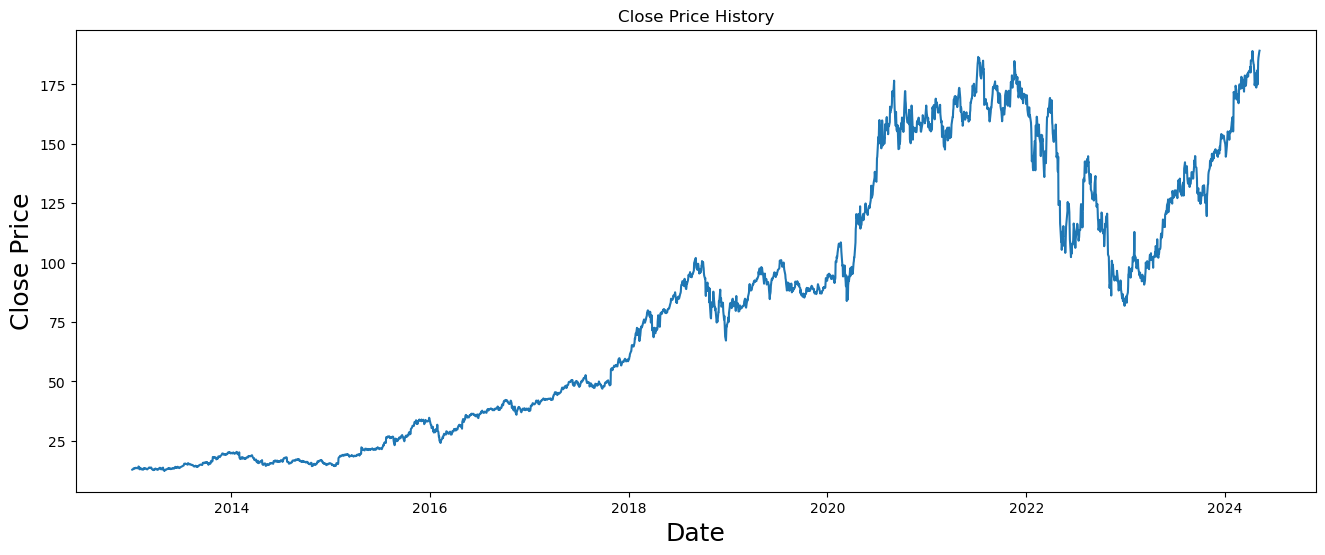

In [48]:
# Closing Price
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(AMZ_df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

In [49]:
# Removing row that contains NAN values
AMZ_df.dropna(inplace=True)

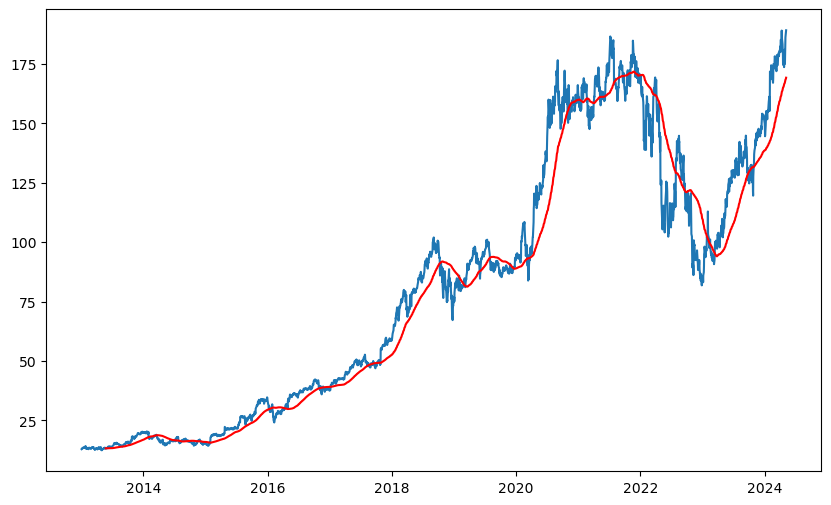

In [50]:
# Rolling average for 100days
ma100 = AMZ_df.Close.rolling(100).mean()
plt.figure(figsize = (10,6))
plt.plot(AMZ_df.Close)
plt.plot(ma100, 'r')

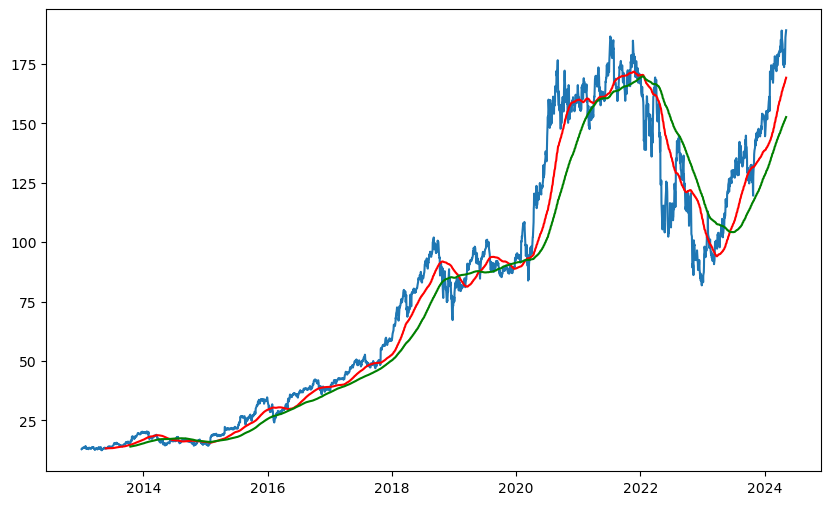

In [51]:
# Rolling average for 200days
ma200 = AMZ_df.Close.rolling(200).mean()
plt.figure(figsize = (10,6))
plt.plot(AMZ_df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [52]:
# Traditional machine learning for stock prediction KNN, random Forest, Support Vector Machines (SVM).

In [53]:

AMZ_df.reset_index(inplace=True)

In [54]:
# Making Date as a column
columns = AMZ_df.columns

In [55]:
AMZ_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2856 non-null   datetime64[ns]
 1   Open       2856 non-null   float64       
 2   High       2856 non-null   float64       
 3   Low        2856 non-null   float64       
 4   Close      2856 non-null   float64       
 5   Adj Close  2856 non-null   float64       
 6   Volume     2856 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 156.3 KB


In [56]:
AMZ_df.set_index('Date', inplace=True)

In [57]:
# Getting the value for feature
AMZ_df['Open - Close'] = AMZ_df['Open'] - AMZ_df['Close']
AMZ_df['High - Low'] = AMZ_df['High'] - AMZ_df['Low']

In [58]:
S= AMZ_df[['Open - Close', 'High - Low']]
S.head(10)

,Open - Close,High - Low
Date,,
2013-01-02,-0.061501,0.242000
2013-01-03,-0.060500,0.225500
2013-01-04,-0.078501,0.157499
2013-01-07,-0.274500,0.353000
2013-01-08,0.034500,0.270500
2013-01-09,0.091000,0.205000
2013-01-10,0.160000,0.322001
2013-01-11,-0.142000,0.216001
2013-01-14,-0.236501,0.336000


In [59]:
# Target value
T = AMZ_df['Close']

In [60]:
# Creating a KNN
s_train_reg, s_test_reg, t_train_reg, t_test_reg = train_test_split(S, T, test_size = 0.25, random_state = 40)


knn_reg = KNeighborsRegressor(n_neighbors = 5)

#fit the model
knn_reg.fit(s_train_reg, t_train_reg)


prediction_Knn_AMZ = knn_reg.predict(s_test_reg)

AMZ_mse = mean_squared_error(t_test_reg, prediction_Knn_AMZ)
print(f'Mean Squared Error: {AMZ_mse}')
print(f'R2: {r2_score(t_test_reg, prediction_Knn_AMZ)}')
AMZ_r2 = r2_score(t_test_reg, prediction_Knn_AMZ)

Mean Squared Error: 858.4183170009431
R2: 0.7132551265283669


In [61]:
# rmse (Root Mean Square Error)
AMZ_rms = np.sqrt(np.mean(np.power((np.array(t_test_reg) -np.array(prediction_Knn_AMZ)), 2)))
AMZ_rms

29.29877671509415

In [62]:
# Create a Random Forest regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_reg.fit(s_train_reg, t_train_reg)

# Make predictions on the test set
prediction_rf_AMZ = rf_reg.predict(s_test_reg)

# Evaluate the model
AMZ_rf_mse = mean_squared_error(t_test_reg, prediction_rf_AMZ)
print(f'Mean Squared Error: {AMZ_rf_mse}')
print(f'R2: {r2_score(t_test_reg, prediction_rf_AMZ)}')
AMZ_rf_r2 = r2_score(t_test_reg, prediction_rf_AMZ)

Mean Squared Error: 857.3330812938218
R2: 0.7136176371707453


In [63]:
# rmse (Root Mean Square Error)
AMZ_rms_rf = np.sqrt(np.mean(np.power((np.array(t_test_reg) -np.array(prediction_rf_AMZ)), 2)))
AMZ_rms_rf

29.28025070408076

In [64]:
# Create an SVR model
svm_reg = SVR(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', etc.

# Fit the model to the training data
svm_reg.fit(s_train_reg, t_train_reg)

# Make predictions on the test set
prediction_svm_AMZ = svm_reg.predict(s_test_reg)

# Evaluate the model using Mean Squared Error
AMZ_mse_svm = mean_squared_error(t_test_reg, prediction_svm_AMZ)
print(f'Mean Squared Error: {AMZ_mse_svm}')
print(f'R2: {r2_score(t_test_reg, prediction_svm_AMZ)}')
AMZ_svm_r2 = r2_score(t_test_reg, prediction_svm_AMZ)

Mean Squared Error: 1654.4586331817698
R2: 0.44734691462177134


In [65]:
# rmse (Root Mean Square Error)
AMZ_rms_svm = np.sqrt(np.mean(np.power((np.array(t_test_reg) -np.array(prediction_svm_AMZ)), 2)))
AMZ_rms_svm

40.67503697824711

In [66]:
#prediction_Amazon

Actual_predicted_AMZ = pd.DataFrame({'Actual Class': t_test_reg, 'Knn_reg Predicted Class': prediction_Knn_AMZ, 'Rf_reg Predicted Class': prediction_rf_AMZ, 'svm_reg Predicted Class': prediction_svm_AMZ})

Actual_predicted_AMZ.tail(10)

,Actual Class,Knn_reg Predicted Class,Rf_reg Predicted Class,svm_reg Predicted Class
Date,,,,
2021-04-07,163.969498,154.150000,134.191915,139.345454
2023-03-13,92.430000,137.139400,133.647543,192.372726
2021-09-02,173.156006,132.093701,161.582154,98.453577
2021-10-18,172.337006,117.585402,124.036911,118.877002
2013-09-03,14.440000,17.157400,16.600610,33.873335
2022-06-30,106.209999,151.903598,146.551304,175.475280
2020-07-15,150.443497,159.201801,156.211981,188.102352
2017-08-10,47.846001,65.009701,63.693225,55.949682
2014-09-08,17.117001,26.170200,22.316540,32.513349


In [67]:
# Building LSTM Model

In [113]:
AMZ_data = AMZ_df.filter(['Close'])
AMZ_dataset = AMZ_data.values

In [114]:
AMZ_training_data_len = int(np.ceil( len(AMZ_dataset) * .80 ))
AMZ_training_data_len

2285

In [115]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
AMZ_scaled_data = scaler.fit_transform(AMZ_dataset)

In [116]:
# Create the training data set & scaled training data set
AMZ_train_data = AMZ_scaled_data[0:int(AMZ_training_data_len), :]
# Split the data into x_train and y_train data sets
L_s_train = []
L_t_train = []

for i in range(100, len(AMZ_train_data)):
    L_s_train.append(AMZ_train_data[i-100:i, 0])
    L_t_train.append(AMZ_train_data[i, 0])
    if i<= 61:
        print(L_s_train)
        print(L_t_train)
        print()
        
# Convert the L_s_train and L_t_train to numpy arrays 
L_s_train, L_t_train = np.array(L_s_train), np.array(L_t_train)

# Reshape the data
L_s_train = np.reshape(L_s_train, (L_s_train.shape[0], L_s_train.shape[1], 1))

In [83]:


model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((L_s_train.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = [ 'mean_squared_error'])

model.fit(L_s_train,L_t_train, epochs = 50, batch_size =32, verbose =1)



Epoch 1/50
69/69 [==============================] - 22s 244ms/step - loss: 0.0371 - mean_squared_error: 0.0371
Epoch 2/50
69/69 [==============================] - 16s 236ms/step - loss: 0.0067 - mean_squared_error: 0.0067
Epoch 3/50
69/69 [==============================] - 16s 231ms/step - loss: 0.0065 - mean_squared_error: 0.0065
Epoch 4/50
69/69 [==============================] - 16s 231ms/step - loss: 0.0070 - mean_squared_error: 0.0070
Epoch 5/50
69/69 [==============================] - 16s 235ms/step - loss: 0.0051 - mean_squared_error: 0.0051
Epoch 6/50
69/69 [==============================] - 16s 233ms/step - loss: 0.0051 - mean_squared_error: 0.0051
Epoch 7/50
69/69 [==============================] - 17s 241ms/step - loss: 0.0053 - mean_squared_error: 0.0053
Epoch 8/50
69/69 [==============================] - 16s 230ms/step - loss: 0.0046 - mean_squared_error: 0.0046
Epoch 9/50
69/69 [==============================] - 16s 229ms/step - loss: 0.0043 - mean_squared_error: 0.0043
E

In [117]:
AMZ_test_data = AMZ_scaled_data[AMZ_training_data_len - 100: , :]
# Create the data sets L_s_test and L_t_test
L_s_test = []
L_t_test = AMZ_dataset[AMZ_training_data_len:, :]
for i in range(100, len(AMZ_test_data)):
    L_s_test.append(AMZ_test_data[i-100:i, 0])
    
# Convert the data to a numpy array
L_s_test = np.array(L_s_test)

# Reshape the data
L_s_test = np.reshape(L_s_test, (L_s_test.shape[0], L_s_test.shape[1], 1 ))

# Get the models predicted price values 
AMZ_predictions = model.predict(L_s_test)
AMZ_predictions = scaler.inverse_transform(AMZ_predictions)

18/18 [==============================] - 1s 65ms/step


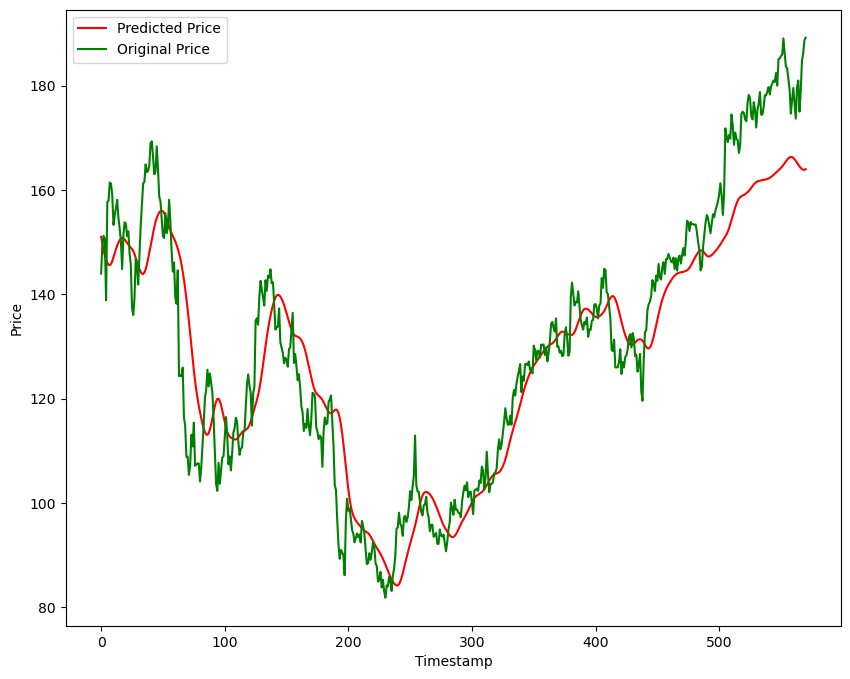

In [118]:
plt.figure(figsize=(10,8))
plt.plot(AMZ_predictions, 'r', label = 'Predicted Price')
plt.plot(L_t_test, 'g', label = 'Original Price')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

C:\Users\joyma\AppData\Local\Temp\ipykernel_4412\3501109061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AMZ_valid['Predictions'] = AMZ_predictions


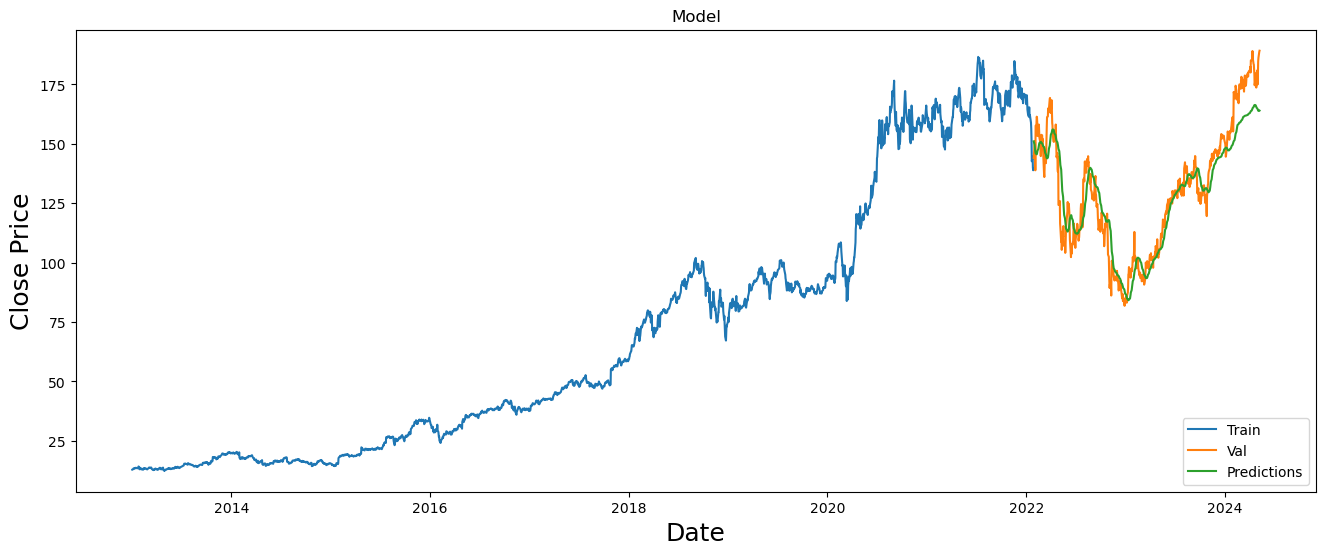

In [119]:
# Plot the data
AMZ_train = AMZ_data[:AMZ_training_data_len]
AMZ_valid = AMZ_data[AMZ_training_data_len:]
AMZ_valid['Predictions'] = AMZ_predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.plot(AMZ_train['Close'])
plt.plot(AMZ_valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


In [120]:
# Calculate R-squared manually
AMZ_r_squared = r2_score(AMZ_data[AMZ_training_data_len:], AMZ_predictions)
print(f'R-squared: {AMZ_r_squared}')

R-squared: 0.8672611331728763


In [121]:
AMZ_mse = mean_squared_error(L_t_test, AMZ_predictions)
AMZ_mse

93.71545540946612

In [122]:
# Get the root mean squared error (RMSE)
AMZ_rmse = np.sqrt(np.mean(((AMZ_predictions - L_t_test) ** 2)))
AMZ_rmse

9.68067432617512

In [123]:
AMZ_valid.tail(10)

,Close,Predictions
Date,,
2024-04-24,176.589996,165.871017
2024-04-25,173.669998,165.562836
2024-04-26,179.619995,165.204697
2024-04-29,180.960007,164.836014
2024-04-30,175.000000,164.510101
2024-05-01,179.000000,164.226898
2024-05-02,184.720001,163.991989
2024-05-03,186.210007,163.849319
2024-05-06,188.699997,163.837784


In [124]:
model.save('AMZ_Stock_Market_Prediction.h5')

In [125]:
R2_result = pd.DataFrame([['Knn', AMZ_r2], ['Rf', AMZ_rf_r2], ['Svm',AMZ_svm_r2], ['Lstm', AMZ_r_squared]], columns=['AMZ_Model', 'Result'])
print(R2_result)

  AMZ_Model    Result
0       Knn  0.713255
1        Rf  0.713618
2       Svm  0.447347
3      Lstm  0.867261


In [126]:
import numpy as np

import lime

from lime import lime_tabular

from keras.models import Sequential

from keras.layers import LSTM, Dropout, Dense

from keras.optimizers import Adam
 

 
# Your existing model code here...
 
# Define a prediction function that LIME can use

def predict_function(x):

    x = x.reshape((x.shape[0], x.shape[1], 1))  # Reshape to (num_samples, sequence_length, 1)

    return model.predict(x)
 
# Create a LimeTabularExplainer

# Note: You need to appropriately define `training_data` and `feature_names` here

explainer = lime_tabular.LimeTabularExplainer(

    training_data=np.random.randn(100,L_s_train.shape[1]),  # Example data; replace with your actual training data

    feature_names=['timestep_{}'.format(i) for i in range(L_s_train.shape[1])],

    mode='regression'

)
 
# Choose a specific instance to explain

instance_index = 1  

instance = L_s_test[instance_index]
 
# Explain the prediction

exp = explainer.explain_instance(

    data_row=instance.flatten(),  # Flatten the sequence to fit LimeTabularExplainer input

    predict_fn=predict_function

)
 
# Display the explanation

exp.show_in_notebook(show_table=True)


157/157 [==============================] - 11s 68ms/step


# Model for Microsoft Stock

In [72]:
# Get the stock quote for Microsoft
MS_df = pdr.get_data_yahoo('MSFT', start='2013-01-01', end=datetime.now())
#Show tech data
MS_df

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-01-02,27.250000,27.730000,27.150000,27.620001,22.532846,52899300
2013-01-03,27.629999,27.650000,27.160000,27.250000,22.231001,48294400
2013-01-04,27.270000,27.340000,26.730000,26.740000,21.814936,52521100
2013-01-07,26.770000,26.879999,26.639999,26.690001,21.774143,37110400
2013-01-08,26.750000,26.790001,26.459999,26.549999,21.659929,44703100
...,...,...,...,...,...,...
2024-05-01,392.609985,401.720001,390.309998,394.940002,394.940002,23562500
2024-05-02,397.660004,399.929993,394.649994,397.839996,397.839996,17709400
2024-05-03,402.279999,407.149994,401.859985,406.660004,406.660004,17446700


In [73]:
MS_df.shape[0]

2856

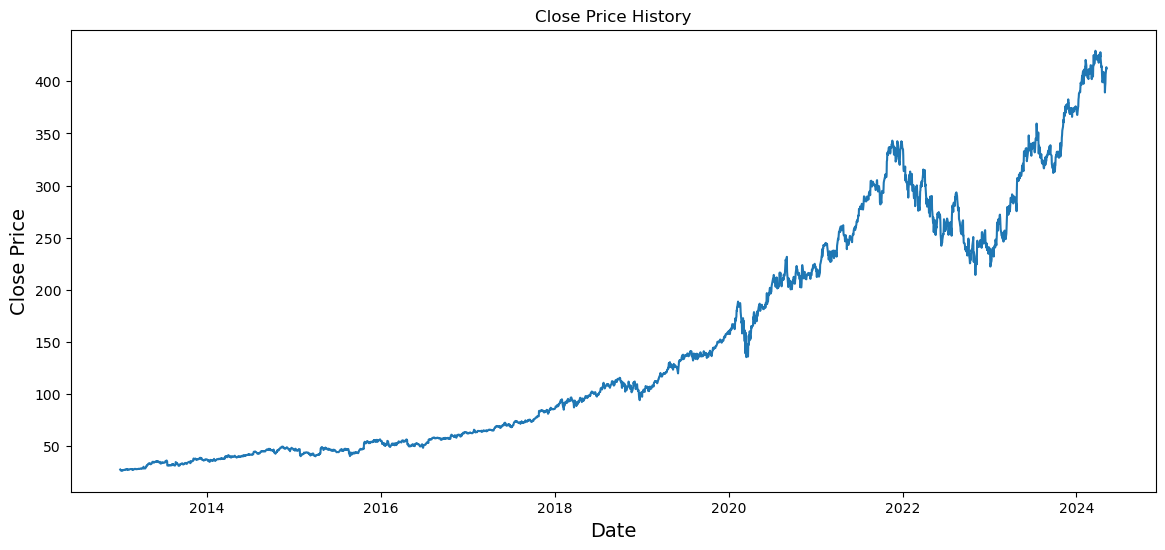

In [74]:
# Closing Price
plt.figure(figsize=(14,6))
plt.title('Close Price History')
plt.plot(MS_df['Close'])
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)
plt.show()

In [75]:
# Removing row that contains NAN values
MS_df.dropna(inplace=True)

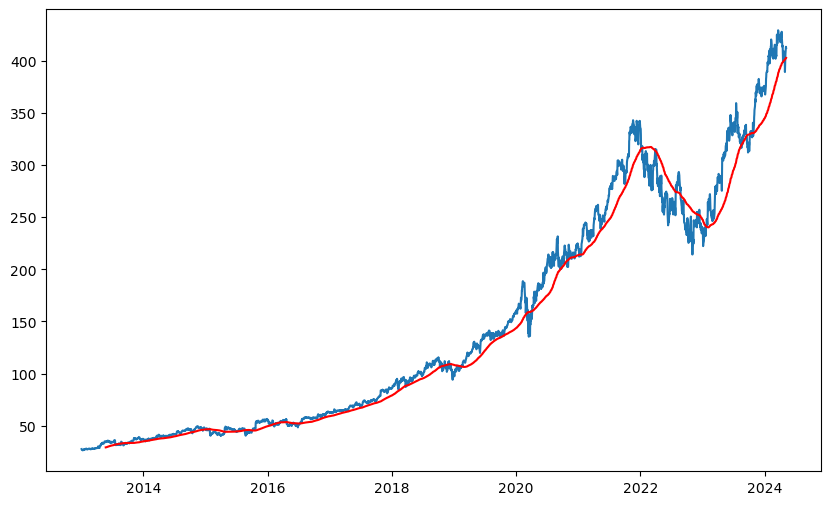

In [76]:
# Rolling average for 100days
ma100 = MS_df.Close.rolling(100).mean()
plt.figure(figsize = (10,6))
plt.plot(MS_df.Close)
plt.plot(ma100, 'r')

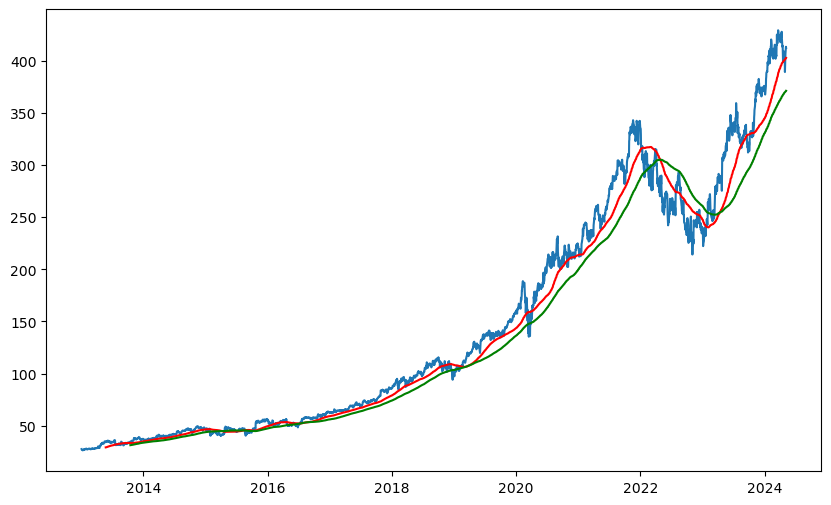

In [77]:
# Rolling average for 200days
ma200 = MS_df.Close.rolling(200).mean()
plt.figure(figsize = (10,6))
plt.plot(MS_df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [78]:
# Traditional machine learning for stock prediction KNN, random Forest, Support Vector Machines (SVM).

In [79]:
MS_df.reset_index(inplace=True)

In [80]:
# Making Date as a column
columns = MS_df.columns

In [81]:
MS_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2856 non-null   datetime64[ns]
 1   Open       2856 non-null   float64       
 2   High       2856 non-null   float64       
 3   Low        2856 non-null   float64       
 4   Close      2856 non-null   float64       
 5   Adj Close  2856 non-null   float64       
 6   Volume     2856 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 156.3 KB


In [82]:
MS_df.set_index('Date', inplace=True)

In [83]:
# Getting the value for features
MS_df['Open - Close'] = MS_df['Open'] - MS_df['Close']
MS_df['High - Low'] = MS_df['High'] - MS_df['Low']

In [84]:
A = MS_df[['Open - Close', 'High - Low']]
A.head(10)

,Open - Close,High - Low
Date,,
2013-01-02,-0.370001,0.580000
2013-01-03,0.379999,0.490000
2013-01-04,0.530001,0.610001
2013-01-07,0.080000,0.240000
2013-01-08,0.200001,0.330002
2013-01-09,0.019999,0.190001
2013-01-10,0.190001,0.689999
2013-01-11,-0.340000,0.650000
2013-01-14,0.010000,0.320000


In [85]:
# Target value
B = MS_df['Close']


In [86]:
# Creating a KNN
a_train_reg, a_test_reg, b_train_reg, b_test_reg = train_test_split(A, B, test_size = 0.25, random_state = 40)


knn_reg = KNeighborsRegressor(n_neighbors = 5)

#fit the model
knn_reg.fit(a_train_reg, b_train_reg)


prediction_Knn_MS = knn_reg.predict(a_test_reg)

MS_mse = mean_squared_error(b_test_reg, prediction_Knn_MS)
print(f'Mean Squared Error: {MS_mse}')
print(f'R2: {r2_score(b_test_reg, prediction_Knn_MS)}')
MS_r2 = r2_score(b_test_reg, prediction_Knn_MS)


Mean Squared Error: 2912.3540956304937
R2: 0.7542057278297902


In [87]:
# rmse (Root Mean Square Error)
MS_rms = np.sqrt(np.mean(np.power((np.array(b_test_reg) -np.array(prediction_Knn_MS)), 2)))
MS_rms

53.96623106749714

In [88]:
# Create a Random Forest regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_reg.fit(a_train_reg, b_train_reg)

# Make predictions on the test set
prediction_rf_MS = rf_reg.predict(a_test_reg)

# Evaluate the model
MS_rf_mse = mean_squared_error(b_test_reg, prediction_rf_MS)
print(f'Mean Squared Error: {MS_rf_mse}')
print(f'R2: {r2_score(b_test_reg, prediction_rf_MS)}')
MS_rf_r2 = r2_score(b_test_reg, prediction_rf_MS)

Mean Squared Error: 2716.8322642307667
R2: 0.770707205556824


In [89]:
# rmse (Root Mean Square Error)
MS_rms_rf = np.sqrt(np.mean(np.power((np.array(b_test_reg) -np.array(prediction_rf_MS)), 2)))
MS_rms_rf

52.123241114024815

In [90]:
# Create an SVR model
svm_reg = SVR(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', etc.

# Fit the model to the training data
svm_reg.fit(a_train_reg, b_train_reg)

# Make predictions on the test set
prediction_svm_MS = svm_reg.predict(a_test_reg)

# Evaluate the model using Mean Squared Error
MS_mse_svm = mean_squared_error(b_test_reg, prediction_svm_MS)
print(f'Mean Squared Error: {MS_mse_svm}')
print(f'R2: {r2_score(b_test_reg, prediction_svm_MS)}')
MS_svm_r2 = r2_score(b_test_reg, prediction_svm_MS)

Mean Squared Error: 6939.503754752528
R2: 0.4143259306342789


In [91]:
# rmse (Root Mean Square Error)
MS_rms_svm = np.sqrt(np.mean(np.power((np.array(b_test_reg) -np.array(prediction_svm_MS)), 2)))
MS_rms_svm

83.3036839206558

In [92]:
#prediction_Microsoft

Actual_predicted_MS = pd.DataFrame({'Actual Class': b_test_reg, 'Knn_reg Predicted Class': prediction_Knn_MS, 'Rf_reg Predicted Class': prediction_rf_MS, 'svm_reg Predicted Class': prediction_svm_MS})

Actual_predicted_MS.tail(10)

,Actual Class,Knn_reg Predicted Class,Rf_reg Predicted Class,svm_reg Predicted Class
Date,,,,
2021-04-07,249.899994,285.175996,243.320199,180.829352
2023-03-13,253.919998,298.590002,270.974800,518.131046
2021-09-02,301.149994,157.848001,202.248604,139.550527
2021-10-18,307.290009,285.985999,260.856197,256.585990
2013-09-03,31.879999,67.685999,61.655599,59.836267
2022-06-30,256.829987,362.854004,342.637509,270.915809
2020-07-15,208.039993,320.827994,280.234694,250.245226
2017-08-10,71.410004,57.332000,60.233299,57.908260
2014-09-08,46.470001,47.468000,53.695001,63.055497


In [93]:
#Using LSTM

In [94]:
MS_data = MS_df.filter(['Close'])
MS_dataset = MS_data.values

In [95]:
MS_training_data_len = int(np.ceil( len(MS_dataset) * .80 ))
MS_training_data_len

2285

In [96]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
MS_scaled_data = scaler.fit_transform(MS_dataset)


In [97]:
# Create the training data set & scaled training data set
MS_train_data = MS_scaled_data[0:int(MS_training_data_len), :]
# Split the data into x_train and y_train data sets
L_a_train = []
L_b_train = []

for i in range(100, len(MS_train_data)):
    L_a_train.append(MS_train_data[i-100:i, 0])
    L_b_train.append(MS_train_data[i, 0])
    if i<= 61:
        print(L_a_train)
        print(L_b_train)
        print()
        
# Convert the L_a_train and L_b_train to numpy arrays 
L_a_train, L_b_train = np.array(L_a_train), np.array(L_b_train)

# Reshape the data
L_a_train = np.reshape(L_a_train, (L_a_train.shape[0], L_a_train.shape[1], 1))

In [98]:

# Define your model architecture

model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((L_a_train.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = [ 'mean_squared_error'])

model.fit(L_a_train,L_b_train, epochs = 50, batch_size =32, verbose =1)



Epoch 1/50
69/69 [==============================] - 19s 179ms/step - loss: 0.0126 - mean_squared_error: 0.0126
Epoch 2/50
69/69 [==============================] - 13s 190ms/step - loss: 0.0030 - mean_squared_error: 0.0030
Epoch 3/50
69/69 [==============================] - 16s 234ms/step - loss: 0.0028 - mean_squared_error: 0.0028
Epoch 4/50
69/69 [==============================] - 13s 189ms/step - loss: 0.0024 - mean_squared_error: 0.0024
Epoch 5/50
69/69 [==============================] - 13s 192ms/step - loss: 0.0029 - mean_squared_error: 0.0029
Epoch 6/50
69/69 [==============================] - 13s 190ms/step - loss: 0.0020 - mean_squared_error: 0.0020
Epoch 7/50
69/69 [==============================] - 13s 188ms/step - loss: 0.0019 - mean_squared_error: 0.0019
Epoch 8/50
69/69 [==============================] - 14s 197ms/step - loss: 0.0021 - mean_squared_error: 0.0021
Epoch 9/50
69/69 [==============================] - 16s 226ms/step - loss: 0.0020 - mean_squared_error: 0.0020
E

In [99]:
MS_test_data = MS_scaled_data[MS_training_data_len - 100: , :]
# Create the data sets L_a_test and L_b_test
L_a_test = []
L_b_test = MS_dataset[MS_training_data_len:, :]
for i in range(100, len(MS_test_data)):
    L_a_test.append(MS_test_data[i-100:i, 0])
    
# Convert the data to a numpy array
L_a_test = np.array(L_a_test)

# Reshape the data
L_a_test = np.reshape(L_a_test, (L_a_test.shape[0], L_a_test.shape[1], 1 ))

# Get the models predicted price values 
MS_predictions = model.predict(L_a_test)
MS_predictions = scaler.inverse_transform(MS_predictions)

18/18 [==============================] - 2s 70ms/step


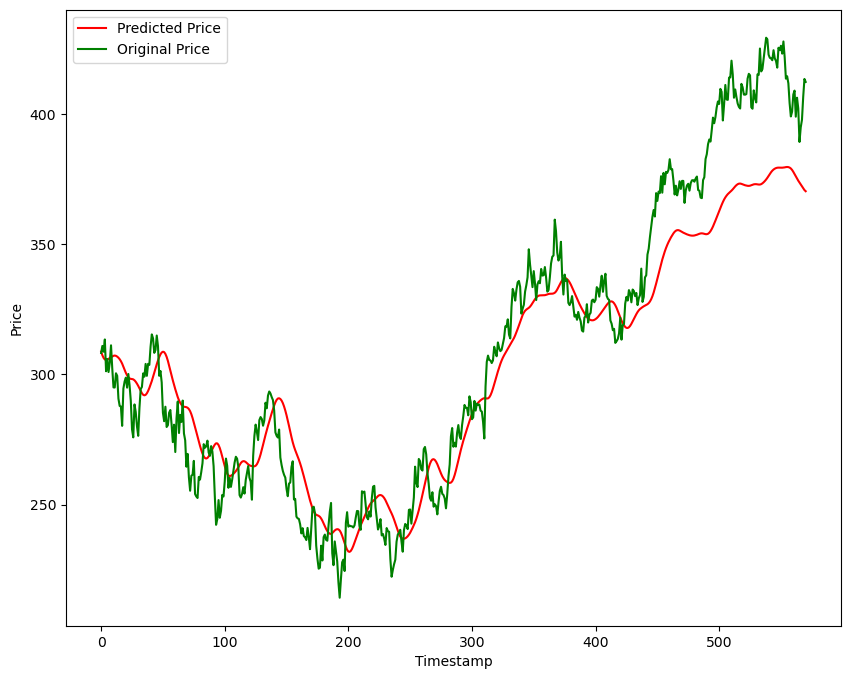

In [100]:
plt.figure(figsize=(10,8))
plt.plot(MS_predictions, 'r', label = 'Predicted Price')
plt.plot(L_b_test, 'g', label = 'Original Price')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

C:\Users\joyma\AppData\Local\Temp\ipykernel_4412\2987149703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MS_valid['Predictions'] = MS_predictions


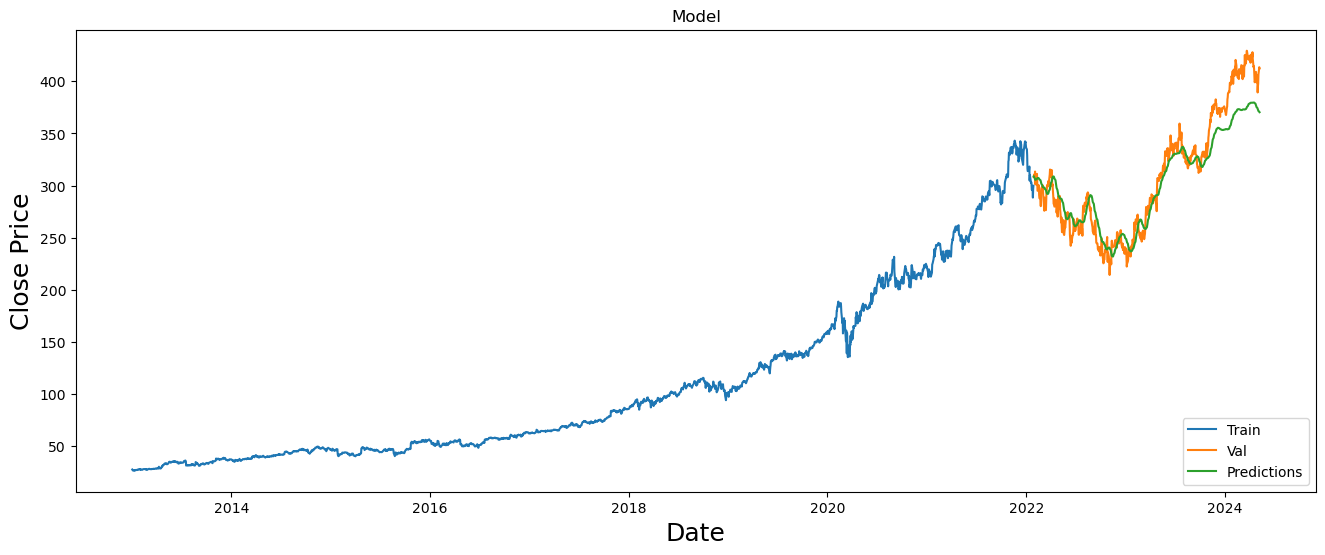

In [101]:
# Plot the data
MS_train = MS_data[:MS_training_data_len]
MS_valid = MS_data[MS_training_data_len:]
MS_valid['Predictions'] = MS_predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.plot(MS_train['Close'])
plt.plot(MS_valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [102]:
# Calculate R-squared manually
MS_r_squared = r2_score(MS_data[MS_training_data_len:], MS_predictions)
print(f'R-squared: {MS_r_squared}')

R-squared: 0.8830472675362924


In [103]:
MS_mse = mean_squared_error(L_b_test, MS_predictions)
MS_mse

379.49840803408176

In [104]:
# Get the root mean squared error (RMSE)
MS_rmse = np.sqrt(np.mean(((MS_predictions - L_b_test) ** 2)))
MS_rmse

19.480718878780674

In [105]:
MS_valid.tail(10)

,Close,Predictions
Date,,
2024-04-24,409.059998,376.988708
2024-04-25,399.040009,376.121094
2024-04-26,406.320007,375.265991
2024-04-29,402.250000,374.462250
2024-04-30,389.329987,373.732452
2024-05-01,394.940002,373.008667
2024-05-02,397.839996,372.260590
2024-05-03,406.660004,371.514526
2024-05-06,413.540009,370.857178


In [106]:

model.save('MS_Stock_Market_Prediction.h5')

In [107]:

R2_result = pd.DataFrame([['Knn', MS_r2], ['Rf', MS_rf_r2], ['Svm', MS_svm_r2], ['Lstm', MS_r_squared]], columns=['MS_Model', 'Result'])
print(R2_result)


  MS_Model    Result
0      Knn  0.754206
1       Rf  0.770707
2      Svm  0.414326
3     Lstm  0.883047


In [108]:

import numpy as np

import lime

from lime import lime_tabular

from keras.models import Sequential

from keras.layers import LSTM, Dropout, Dense

from keras.optimizers import Adam
 

 
# Your existing model code here...
 
# Define a prediction function that LIME can use

def predict_function(x):

    x = x.reshape((x.shape[0], x.shape[1], 1))  # Reshape to (num_samples, sequence_length, 1)

    return model.predict(x)
 
# Create a LimeTabularExplainer

# Note: You need to appropriately define `training_data` and `feature_names` here

explainer = lime_tabular.LimeTabularExplainer(

    training_data=np.random.randn(100,L_a_train.shape[1]),  # Example data; replace with your actual training data

    feature_names=['timestep_{}'.format(i) for i in range(L_a_train.shape[1])],

    mode='regression'

)
 
# Choose a specific instance to explain

instance_index = 1  

instance = L_a_test[instance_index]
 
# Explain the prediction

exp = explainer.explain_instance(

    data_row=instance.flatten(),  # Flatten the sequence to fit LimeTabularExplainer input

    predict_fn=predict_function

)
 
# Display the explanation

exp.show_in_notebook(show_table=True)


157/157 [==============================] - 11s 67ms/step
